# First Model

Attempt to train a simple net using all the features we have amassed. 

What we've figured out:
- SMOTE: stick to 'minority' rather than 'not majority' setting, keep k value the same
- We get best loss of <0.7, much better than the random classifier loss of ~1.0
- We've fixed hyperparameters (batch size, epochs, LR), model architecture (num layers, dims, dropout), features (rolling window size)

What's left:
- better metrics than accuracy
- save graphs for different model configurations, then follow the paper (ex: SHAP stuff)
- write up paper

In [1]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from scipy.sparse import hstack
from torch import nn
from tqdm import tqdm
from torch.utils.data import TensorDataset, DataLoader
from imblearn.over_sampling import SMOTE

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

## Collect the data

In [3]:
# read the csvs
beige_df = pd.read_csv("data/beige_book_1996_2025.csv")
labels_df = pd.read_csv("data/filtered_labels.csv")
lm_sentiment_df = pd.read_csv('data/beige_book_sentiment_scores_1996_2025.csv')
market_futures_df = pd.read_csv('data/futures_with_diff.csv')

# column to merge on is timestamp
labels_df['timestamp'] = labels_df['observation_date']
market_futures_df['timestamp'] = market_futures_df['exp_date']
beige_df = pd.merge(beige_df, labels_df, on='timestamp', how='inner')
beige_df = pd.merge(beige_df, lm_sentiment_df, on='timestamp', how='inner')
beige_df = pd.merge(beige_df, market_futures_df, on='timestamp', how='inner')

# process the columns
beige_df['text'] = beige_df['text_x']
beige_df['url'] = beige_df['url_x']
beige_df['month'] = beige_df['month_x']
beige_df['year'] = beige_df['year_x']
beige_df = beige_df.drop(['year_x', 'month_x', 'url_x', 'text_x'], axis=1)
beige_df = beige_df.drop(['Unnamed: 0', 'Unnamed: 0_x', 'Unnamed: 0_y', 'observation_date', 'exp_date'], axis=1)
beige_df = beige_df.drop(['year_y', 'month_y', 'url_y', 'text_y'], axis=1)

# add average for new columns
beige_df['negative_score_10_mean'] = beige_df['negative_score'].rolling(window=24, min_periods=1).mean().shift(1)
beige_df['positive_score_10_mean'] = beige_df['positive_score'].rolling(window=24, min_periods=1).mean().shift(1)
beige_df['uncertainty_score_10_mean'] = beige_df['uncertainty_score'].rolling(window=24, min_periods=1).mean().shift(1)
beige_df['futures_price_10_mean'] = beige_df['futures_price'].rolling(window=24, min_periods=1).mean().shift(1)
beige_df['implied_rate_10_mean'] = beige_df['implied_rate'].rolling(window=24, min_periods=1).mean().shift(1)
beige_df['implied_rate_diff_10_mean'] = beige_df['implied_rate_diff'].rolling(window=24, min_periods=1).mean().shift(1)

beige_df = beige_df.drop(index=0) # first row is na

# sort by timestamp
final_df = beige_df.sort_values(by='timestamp')

print(len(final_df))
print(final_df.columns)
final_df.head()

231
Index(['timestamp', 'rate', 'decision', 'negative_score', 'positive_score',
       'uncertainty_score', '52W_high', '52W_low', '52W_pct_chg',
       'futures_price', 'implied_rate', 'implied_rate_diff', 'text', 'url',
       'month', 'year', 'negative_score_10_mean', 'positive_score_10_mean',
       'uncertainty_score_10_mean', 'futures_price_10_mean',
       'implied_rate_10_mean', 'implied_rate_diff_10_mean'],
      dtype='object')


,timestamp,rate,decision,negative_score,positive_score,uncertainty_score,52W_high,52W_low,52W_pct_chg,futures_price,...,text,url,month,year,negative_score_10_mean,positive_score_10_mean,uncertainty_score_10_mean,futures_price_10_mean,implied_rate_10_mean,implied_rate_diff_10_mean
1,1996-12-01,5.25,hold,0.014639,0.024703,0.007319,95.52,94.00,-0.62,94.660,...,moderate economic growth continues to be repor...,https://www.federalreserve.gov/fomc/beigebook/...,12,1996,0.029883,0.029883,0.010204,94.750000,5.250000,-0.04500
2,1997-01-01,5.25,hold,0.035156,0.026367,0.004883,95.52,93.90,-0.63,94.745,...,most district reports characterized early autu...,https://www.federalreserve.gov/fomc/beigebook/...,1,1997,0.022261,0.027293,0.008762,94.705000,5.295000,-0.01750
3,1997-03-01,5.25,hold,0.023581,0.020087,0.006114,94.73,93.68,0.57,94.635,...,district economies generally continue to expan...,https://www.federalreserve.gov/fomc/beigebook/...,3,1997,0.026559,0.026984,0.007469,94.718333,5.281667,-0.04000
4,1997-05-01,5.50,raise,0.027429,0.028997,0.001567,94.70,93.79,0.54,94.490,...,district economies generally continued to expa...,https://www.federalreserve.gov/fomc/beigebook/...,5,1997,0.025815,0.025260,0.007130,94.697500,5.302500,0.01625
5,1997-06-01,5.50,hold,0.031159,0.018116,0.005797,94.68,94.29,0.10,94.465,...,all twelve district economies expanded in may ...,https://www.federalreserve.gov/fomc/beigebook/...,6,1997,0.026138,0.026007,0.006017,94.656000,5.344000,0.01300


# Feature Engineering?

In [4]:
# standardize the labels (so numeric labels of 0, 1, 2) - raise: 2, hold: 0, lower: 1
label_encoder = LabelEncoder()
final_df['labels'] = label_encoder.fit_transform(final_df['decision'])

In [5]:
# train-test split (70-15-15 split)
X = final_df[['timestamp', 'rate', 'negative_score', 'positive_score',
        'uncertainty_score', '52W_high', '52W_low', '52W_pct_chg',
        'futures_price', 'implied_rate', 'implied_rate_diff', 'text', 'url',
        'month', 'year', 'negative_score_10_mean', 'positive_score_10_mean',
        'uncertainty_score_10_mean', 'futures_price_10_mean',
        'implied_rate_10_mean', 'implied_rate_diff_10_mean']]
y = final_df['labels']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, random_state=seed, test_size=0.3, shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, random_state=seed, test_size=0.5, shuffle=True)

print(len(X_train), len(X_val), len(X_test))

161 35 35


In [6]:
# generate TF-IDF encodings for the text
tf_idf_vectorizer = TfidfVectorizer()
X_text_train = tf_idf_vectorizer.fit_transform(X_train['text'])
X_text_val = tf_idf_vectorizer.transform(X_val['text'])
X_text_test = tf_idf_vectorizer.transform(X_test['text'])

print(X_text_train.shape, X_text_val.shape, X_text_test.shape)


(161, 8602) (35, 8602) (35, 8602)


In [7]:
scaler = StandardScaler()
columns_to_scale = ['rate', 'negative_score', 'positive_score', 'uncertainty_score', '52W_high', '52W_low', '52W_pct_chg', 'futures_price', 'implied_rate', 'implied_rate_diff', 'negative_score_10_mean', 'positive_score_10_mean',
        'uncertainty_score_10_mean', 'futures_price_10_mean', 'implied_rate_10_mean', 'implied_rate_diff_10_mean']

X_nums_train = scaler.fit_transform(X_train[columns_to_scale])
X_nums_val   = scaler.transform(X_val[columns_to_scale])
X_nums_test  = scaler.transform(X_test[columns_to_scale])

print(X_nums_train.shape, X_nums_val.shape, X_nums_test.shape)

(161, 16) (35, 16) (35, 16)


In [8]:
X_train = hstack([X_nums_train, X_text_train])
X_val = hstack([X_nums_val, X_text_val])
X_test = hstack([X_nums_test, X_text_test])

print(X_train.shape, X_val.shape, X_test.shape)

(161, 8618) (35, 8618) (35, 8618)


In [9]:
# SMOTE stuff
smote = SMOTE(sampling_strategy='minority', random_state=seed)
X_train, y_train = smote.fit_resample(X_train, y_train)

## Make the model

In [10]:
class FirstExperimentModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        # input layer, starting with 512 since i've not seen 1024 before, setting high dropout
        self.input_layer = nn.Sequential(nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.3))

        # hidden layer, reducing dims further
        self.hidden_layer = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3))

        self.hidden_layer_2 = nn.Sequential(nn.Linear(128, 32), nn.ReLU(), nn.Dropout(0.3))

        # output layer without softmax
        self.output_layer = nn.Linear(32, 3)

        # all together now
        self.net = nn.Sequential(self.input_layer, self.hidden_layer, self.hidden_layer_2, self.output_layer)
    
    def forward(self, x):
        return self.net(x)
    
model = FirstExperimentModel(X_train.shape[1])
model.to(device)
print(model.net)

Sequential(
  (0): Sequential(
    (0): Linear(in_features=8618, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (1): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (2): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (3): Linear(in_features=32, out_features=3, bias=True)
)


In [11]:
# define cost-sensitive loss function
# inspiration: https://medium.com/nerd-for-tech/review-cb-loss-class-balanced-loss-based-on-effective-number-of-samples-image-classification-3056a1a1a001
weights = 1.0 / np.bincount(y_train.values)
weights = weights / weights.sum()
weights = torch.tensor(weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, device=device))

lr = 0.0001 # making this v small since we have less data
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

/var/folders/tx/z8m55vy91yn1d7txz9n0s2kr0000gn/T/ipykernel_43676/2746057137.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, device=device))


## Training Loop

TODO: figure out how to save the best model by tracking the best validation error seen per epoch

In [12]:
num_epochs = 50 # idk apparently for tf-idf you need large epochs
batch_size = 32 # this is sort of random (smaller might work better since we have less data to begin with)

In [13]:
# heavily copied from HW4

def train(data_loader, model, criterion, optimizer, device):
    train_avg_loss = 0
    num_correct = 0
    all_preds = []
    all_labels = []

    model.train()
    for feats, labels in data_loader:
        optimizer.zero_grad()
        feats = feats.to(device)
        labels = labels.long().to(device)

        # Perform forward pass and calculate avg loss over all time steps
        logits = model(feats)
        loss = criterion(logits, labels)
        preds = torch.argmax(logits, dim=1)
        num_correct += torch.sum(preds == labels)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

        # Backward pass, update weights
        loss.backward()
        optimizer.step()

        train_avg_loss += loss.item()*feats.shape[0]

    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    accuracy = num_correct.item() / len(data_loader.dataset)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    #print(f"Train loss: {train_avg_loss/len(data_loader.dataset)} | Accuracy: {accuracy} | Precision: {precision} | Recall: {recall} | F1: {f1}")
    return train_avg_loss/len(data_loader.dataset)

def val(data_loader, model, criterion, device):
    val_avg_loss = 0
    num_correct = 0
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for feats, labels in data_loader:
            feats = feats.to(device)
            labels = labels.long().to(device)

            # Perform forward pass and calculate avg loss over all time steps
            logits = model(feats)
            loss = criterion(logits, labels)
            preds = torch.argmax(logits, dim=1)
            num_correct += torch.sum(preds == labels)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

            val_avg_loss += loss.item()*feats.shape[0]

    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    accuracy = num_correct.item() / len(data_loader.dataset)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    #print(f"Val loss: {val_avg_loss/len(data_loader.dataset)} | Accuracy: {accuracy} | Precision: {precision} | Recall: {recall} | F1: {f1}\n")
    return val_avg_loss/len(data_loader.dataset)

In [14]:
X_train_dense = torch.tensor(X_train.toarray(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
train_dataset = TensorDataset(X_train_dense, y_train_tensor)

X_val_dense = torch.tensor(X_val.toarray(), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
val_dataset = TensorDataset(X_val_dense, y_val_tensor)

# shuffling right now but I'm not sure if we should based on timestamps
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

train_loss_list, val_loss_list = [], []
for epoch in range(num_epochs):
    print(f"Epoch {epoch}")
    train_loss_list.append(train(train_dataloader, model, criterion, optimizer, device))
    val_loss_list.append(val(val_dataloader, model, criterion, device))

with open('scores.txt', 'a') as f:
    f.write(f"{batch_size}-{num_epochs}-{lr} | {train_loss_list} | {val_loss_list}\n")

Epoch 0
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19
Epoch 20
Epoch 21
Epoch 22
Epoch 23
Epoch 24
Epoch 25
Epoch 26
Epoch 27
Epoch 28
Epoch 29
Epoch 30
Epoch 31
Epoch 32
Epoch 33
Epoch 34
Epoch 35
Epoch 36
Epoch 37
Epoch 38
Epoch 39
Epoch 40
Epoch 41
Epoch 42
Epoch 43
Epoch 44
Epoch 45
Epoch 46
Epoch 47
Epoch 48
Epoch 49


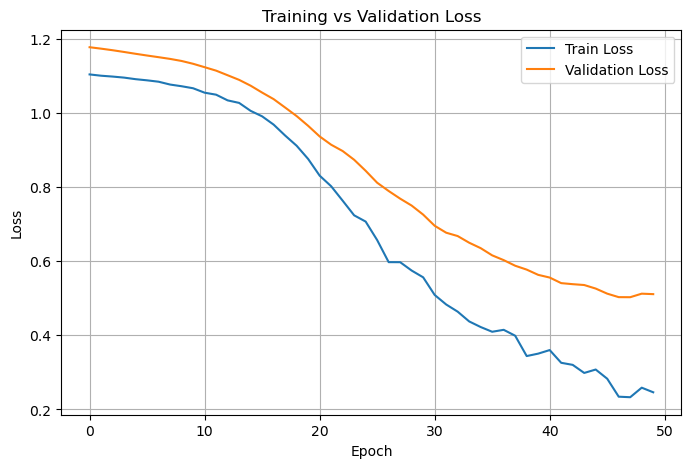

In [15]:
plt.figure(figsize=(8,5))
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
def actual_vs_pred(data_loader, model, device):
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for feats, labels in tqdm(data_loader):
            feats = feats.to(device)
            labels = labels.long().to(device)

            # Perform forward pass
            logits = model(feats)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return pd.DataFrame({"actual": all_labels, "predicted": all_preds})

actual_vs_pred(val_dataloader, model, device)

100%|████████████████████████████████████████████| 2/2 [00:00<00:00, 525.37it/s]


,actual,predicted
0,0,2
1,0,0
2,0,0
3,0,0
4,0,1
5,0,0
6,2,2
7,0,0
8,0,0
9,2,2


In [17]:
final_df['decision'].value_counts()

decision
hold     158
raise     45
lower     28
Name: count, dtype: int64

## Test dataset

In [18]:
X_test_dense = torch.tensor(X_test.toarray(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)
test_dataset = TensorDataset(X_test_dense, y_test_tensor)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
results = actual_vs_pred(test_dataloader, model, device)

100%|████████████████████████████████████████████| 2/2 [00:00<00:00, 338.88it/s]


In [19]:
print(f"Test Accuracy: {accuracy_score(results["actual"], results["predicted"])}")
print(f"Test Precision: {precision_score(results["actual"], results["predicted"], average="macro")}")
print(f"Test Recall: {recall_score(results["actual"], results["predicted"], average="macro")}")
print(f"Test f1: {f1_score(results["actual"], results["predicted"], average="macro")}")
print(f"Test conf_matrix:\n{confusion_matrix(results["actual"], results["predicted"])}")

Test Accuracy: 0.9142857142857143
Test Precision: 0.9666666666666667
Test Recall: 0.7999999999999999
Test f1: 0.8395989974937343
Test conf_matrix:
[[27  0  0]
 [ 3  2  0]
 [ 0  0  3]]


In [28]:
def testing(X_test, y_test, model, device):
    X_test_dense = torch.tensor(X_test.toarray(), dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)
    test_dataset = TensorDataset(X_test_dense, y_test_tensor)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    results = actual_vs_pred(test_dataloader, model, device)
    return results

def training_many_models(model, X_train, y_train, X_val, y_val, X_test, y_test, lr=0.0001, num_epochs=100, batch_size=32):
    weights = 1.0 / np.bincount(y_train.values)
    weights = weights / weights.sum()
    weights = torch.tensor(weights, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, device=device))

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    X_train_dense = torch.tensor(X_train.toarray(), dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
    train_dataset = TensorDataset(X_train_dense, y_train_tensor)
    
    X_val_dense = torch.tensor(X_val.toarray(), dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
    val_dataset = TensorDataset(X_val_dense, y_val_tensor)

    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    train_loss_list, val_loss_list = [], []
    for epoch in range(num_epochs):
        #print(f"Epoch {epoch}")
        train_loss_list.append(train(train_dataloader, model, criterion, optimizer, device))
        val_loss_list.append(val(val_dataloader, model, criterion, device))

    plt.figure(figsize=(8,5))
    plt.plot(train_loss_list, label="Train Loss")
    plt.plot(val_loss_list, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


    results =  testing(X_test, y_test, model, device)#actual_vs_pred(test_dataloader, model, device)

    print(f"Test Accuracy: {accuracy_score(results["actual"], results["predicted"])}")
    print(f"Test Precision: {precision_score(results["actual"], results["predicted"], average="macro")}")
    print(f"Test Recall: {recall_score(results["actual"], results["predicted"], average="macro")}")
    print(f"Test f1: {f1_score(results["actual"], results["predicted"], average="macro")}")
    print(f"Test conf_matrix:\n{confusion_matrix(results["actual"], results["predicted"])}")

    return train_loss_list, val_loss_list, results



Sequential(
  (0): Sequential(
    (0): Linear(in_features=8618, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (1): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (2): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (3): Linear(in_features=32, out_features=3, bias=True)
)


/var/folders/tx/z8m55vy91yn1d7txz9n0s2kr0000gn/T/ipykernel_43676/3497836227.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, device=device))


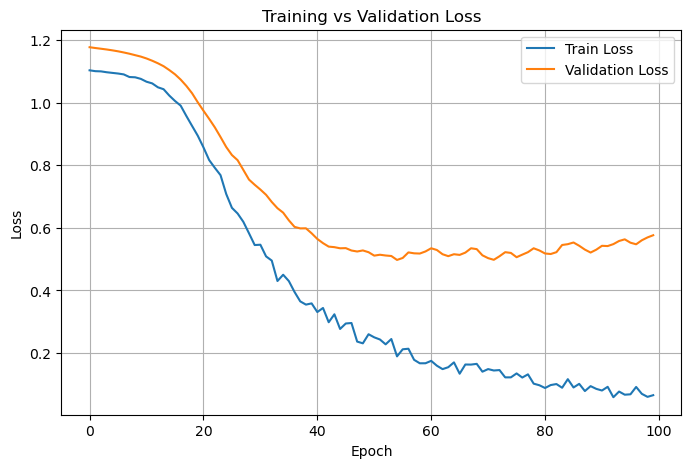

100%|████████████████████████████████████████████| 2/2 [00:00<00:00, 615.99it/s]

Test Accuracy: 0.9142857142857143
Test Precision: 0.9666666666666667
Test Recall: 0.7999999999999999
Test f1: 0.8395989974937343
Test conf_matrix:
[[27  0  0]
 [ 3  2  0]
 [ 0  0  3]]


In [29]:
# Best Model

num_epochs = 100 # idk apparently for tf-idf you need large epochs
batch_size = 32
lr = 0.0001
model1 = FirstExperimentModel(X_train.shape[1])
model1.to(device)
print(model1.net)

train_loss_list1, val_loss_list1, results1 = training_many_models(model1, X_train, y_train, X_val, y_val, X_test, y_test, lr=lr, num_epochs=num_epochs, batch_size=batch_size)

# weights = 1.0 / np.bincount(y_train.values)
# weights = weights / weights.sum()
# weights = torch.tensor(weights, dtype=torch.float32).to(device)
# criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, device=device))

# lr = 0.0001 # making this v small since we have less data
# optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# X_train_dense = torch.tensor(X_train.toarray(), dtype=torch.float32)
# y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
# train_dataset = TensorDataset(X_train_dense, y_train_tensor)

# X_val_dense = torch.tensor(X_val.toarray(), dtype=torch.float32)
# y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
# val_dataset = TensorDataset(X_val_dense, y_val_tensor)

# # shuffling right now but I'm not sure if we should based on timestamps
# train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# train_loss_list1, val_loss_list1 = [], []
# for epoch in range(num_epochs):
#     #print(f"Epoch {epoch}")
#     train_loss_list1.append(train(train_dataloader, model, criterion, optimizer, device))
#     val_loss_list1.append(val(val_dataloader, model, criterion, device))

# plt.figure(figsize=(8,5))
# plt.plot(train_loss_list, label="Train Loss")
# plt.plot(val_loss_list, label="Validation Loss")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Training vs Validation Loss")
# plt.legend()
# plt.grid(True)
# plt.show()

# # X_test_dense = torch.tensor(X_test.toarray(), dtype=torch.float32)
# # y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)
# # test_dataset = TensorDataset(X_test_dense, y_test_tensor)
# # test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# results1 =  testing(X_test, y_test, model, device)#actual_vs_pred(test_dataloader, model, device)

# print(f"Test Accuracy: {accuracy_score(results1["actual"], results1["predicted"])}")
# print(f"Test Precision: {precision_score(results1["actual"], results1["predicted"], average="macro")}")
# print(f"Test Recall: {recall_score(results1["actual"], results1["predicted"], average="macro")}")
# print(f"Test f1: {f1_score(results1["actual"], results1["predicted"], average="macro")}")
# print(f"Test conf_matrix:\n{confusion_matrix(results1["actual"], results1["predicted"])}")

Sequential(
  (0): Sequential(
    (0): Linear(in_features=8618, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (1): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (2): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (3): Linear(in_features=32, out_features=3, bias=True)
)


/var/folders/tx/z8m55vy91yn1d7txz9n0s2kr0000gn/T/ipykernel_43676/3497836227.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, device=device))


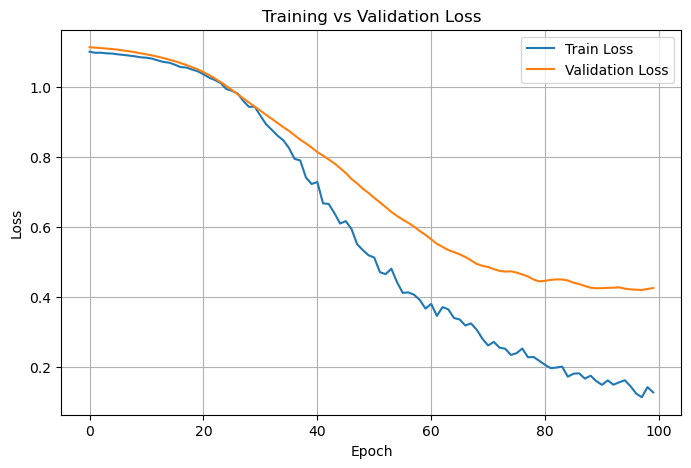

100%|████████████████████████████████████████████| 1/1 [00:00<00:00, 398.70it/s]

Test Accuracy: 0.9142857142857143
Test Precision: 0.9666666666666667
Test Recall: 0.7999999999999999
Test f1: 0.8395989974937343
Test conf_matrix:
[[27  0  0]
 [ 3  2  0]
 [ 0  0  3]]


In [30]:
# increase batch size

num_epochs = 100 # idk apparently for tf-idf you need large epochs
batch_size = 64
lr = 0.0001
model2 = FirstExperimentModel(X_train.shape[1])
model2.to(device)
print(model2.net)

train_loss_list2, val_loss_list2, results2 = training_many_models(model2, X_train, y_train, X_val, y_val, X_test, y_test, lr=lr, num_epochs=num_epochs, batch_size=batch_size)


# weights2 = 1.0 / np.bincount(y_train.values)
# weights2 = weights2 / weights2.sum()
# weights2 = torch.tensor(weights2, dtype=torch.float32).to(device)
# criterion2 = nn.CrossEntropyLoss(weight=torch.tensor(weights2, device=device))

# lr = 0.0001 # making this v small since we have less data
# optimizer2 = torch.optim.Adam(model2.parameters(), lr=lr)

# X_train_dense = torch.tensor(X_train.toarray(), dtype=torch.float32)
# y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
# train_dataset = TensorDataset(X_train_dense, y_train_tensor)

# X_val_dense = torch.tensor(X_val.toarray(), dtype=torch.float32)
# y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
# val_dataset = TensorDataset(X_val_dense, y_val_tensor)

# # shuffling right now but I'm not sure if we should based on timestamps
# train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# train_loss_list2, val_loss_list2 = [], []
# for epoch in range(num_epochs):
#     #print(f"Epoch {epoch}")
#     train_loss_list2.append(train(train_dataloader, model2, criterion2, optimizer2, device))
#     val_loss_list2.append(val(val_dataloader, model2, criterion2, device))

# plt.figure(figsize=(8,5))
# plt.plot(train_loss_list1, label="Train Loss")
# plt.plot(val_loss_list1, label="Validation Loss")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Training vs Validation Loss")
# plt.legend()
# plt.grid(True)
# plt.show()

# # X_test_dense = torch.tensor(X_test.toarray(), dtype=torch.float32)
# # y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)
# # test_dataset = TensorDataset(X_test_dense, y_test_tensor)
# # test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# # results2 = actual_vs_pred(test_dataloader, model2, device)
# results2 =  testing(X_test, y_test, model2, device)

# print(f"Test Accuracy: {accuracy_score(results2["actual"], results2["predicted"])}")
# print(f"Test Precision: {precision_score(results2["actual"], results2["predicted"], average="macro")}")
# print(f"Test Recall: {recall_score(results2["actual"], results2["predicted"], average="macro")}")
# print(f"Test f1: {f1_score(results2["actual"], results2["predicted"], average="macro")}")
# print(f"Test conf_matrix:\n{confusion_matrix(results2["actual"], results2["predicted"])}")

In [ ]:
# decrease batch size

num_epochs = 100 # idk apparently for tf-idf you need large epochs
batch_size = 16
lr = 0.0001
model3 = FirstExperimentModel(X_train.shape[1])
model3.to(device)
print(model3.net)

train_loss_list3, val_loss_list3, results3 = training_many_models(model3, X_train, y_train, X_val, y_val, X_test, y_test, lr=lr, num_epochs=num_epochs, batch_size=batch_size)


# weights3 = 1.0 / np.bincount(y_train.values)
# weights3 = weights3 / weights3.sum()
# weights3 = torch.tensor(weights3, dtype=torch.float32).to(device)
# criterion3 = nn.CrossEntropyLoss(weight=torch.tensor(weights3, device=device))

# lr = 0.0001 # making this v small since we have less data
# optimizer3 = torch.optim.Adam(model3.parameters(), lr=lr)

# X_train_dense = torch.tensor(X_train.toarray(), dtype=torch.float32)
# y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
# train_dataset = TensorDataset(X_train_dense, y_train_tensor)

# X_val_dense = torch.tensor(X_val.toarray(), dtype=torch.float32)
# y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
# val_dataset = TensorDataset(X_val_dense, y_val_tensor)

# # shuffling right now but I'm not sure if we should based on timestamps
# train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# train_loss_list3, val_loss_list3 = [], []
# for epoch in range(num_epochs):
#     #print(f"Epoch {epoch}")
#     train_loss_list3.append(train(train_dataloader, model3, criterion3, optimizer3, device))
#     val_loss_list3.append(val(val_dataloader, model3, criterion3, device))

# plt.figure(figsize=(8,5))
# plt.plot(train_loss_list3, label="Train Loss")
# plt.plot(val_loss_list3, label="Validation Loss")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Training vs Validation Loss")
# plt.legend()
# plt.grid(True)
# plt.show()

# # X_test_dense = torch.tensor(X_test.toarray(), dtype=torch.float32)
# # y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)
# # test_dataset = TensorDataset(X_test_dense, y_test_tensor)
# # test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# # results3 = actual_vs_pred(test_dataloader, model3, device)
# results3 = testing(X_test, y_test, model3, device)

# print(f"Test Accuracy: {accuracy_score(results3["actual"], results3["predicted"])}")
# print(f"Test Precision: {precision_score(results3["actual"], results3["predicted"], average="macro")}")
# print(f"Test Recall: {recall_score(results3["actual"], results3["predicted"], average="macro")}")
# print(f"Test f1: {f1_score(results3["actual"], results3["predicted"], average="macro")}")
# print(f"Test conf_matrix:\n{confusion_matrix(results3["actual"], results3["predicted"])}")

Sequential(
  (0): Sequential(
    (0): Linear(in_features=8618, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (1): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (2): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (3): Linear(in_features=32, out_features=3, bias=True)
)


/var/folders/tx/z8m55vy91yn1d7txz9n0s2kr0000gn/T/ipykernel_43676/3497836227.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, device=device))


/var/folders/tx/z8m55vy91yn1d7txz9n0s2kr0000gn/T/ipykernel_43676/312913402.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  criterion4 = nn.CrossEntropyLoss(weight=torch.tensor(weights4, device=device))


Sequential(
  (0): Sequential(
    (0): Linear(in_features=8618, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (1): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (2): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (3): Linear(in_features=32, out_features=3, bias=True)
)


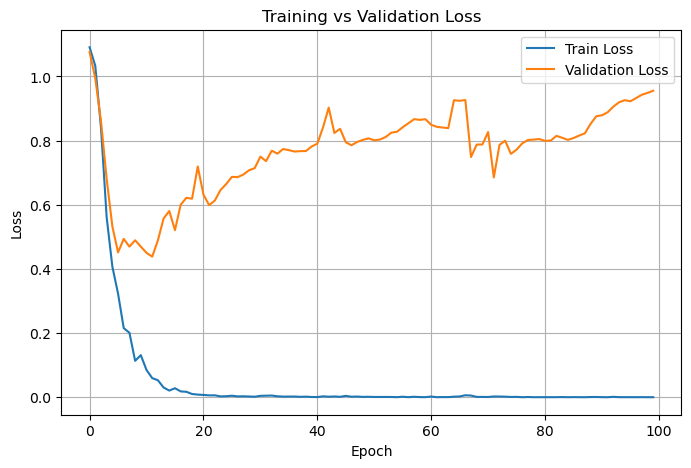

100%|███████████████████████████████████████████| 3/3 [00:00<00:00, 1118.18it/s]

Test Accuracy: 0.8857142857142857
Test Precision: 0.956989247311828
Test Recall: 0.7333333333333334
Test f1: 0.7547892720306514
Test conf_matrix:
[[27  0  0]
 [ 4  1  0]
 [ 0  0  3]]


In [24]:
# increase learning rate
num_epochs = 100 # idk apparently for tf-idf you need large epochs
batch_size = 16
model4 = FirstExperimentModel(X_train.shape[1])
model4.to(device)
print(model4.net)

weights4 = 1.0 / np.bincount(y_train.values)
weights4 = weights4 / weights4.sum()
weights4 = torch.tensor(weights4, dtype=torch.float32).to(device)
criterion4 = nn.CrossEntropyLoss(weight=torch.tensor(weights4, device=device))

lr = 0.001 # making this v small since we have less data
optimizer4 = torch.optim.Adam(model4.parameters(), lr=lr)

X_train_dense = torch.tensor(X_train.toarray(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
train_dataset = TensorDataset(X_train_dense, y_train_tensor)

X_val_dense = torch.tensor(X_val.toarray(), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
val_dataset = TensorDataset(X_val_dense, y_val_tensor)

# shuffling right now but I'm not sure if we should based on timestamps
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

train_loss_list4, val_loss_list4 = [], []
for epoch in range(num_epochs):
    #print(f"Epoch {epoch}")
    train_loss_list4.append(train(train_dataloader, model4, criterion4, optimizer4, device))
    val_loss_list4.append(val(val_dataloader, model4, criterion4, device))

plt.figure(figsize=(8,5))
plt.plot(train_loss_list4, label="Train Loss")
plt.plot(val_loss_list4, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# X_test_dense = torch.tensor(X_test.toarray(), dtype=torch.float32)
# y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)
# test_dataset = TensorDataset(X_test_dense, y_test_tensor)
# test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# results4 = actual_vs_pred(test_dataloader, model4, device)
results4 = testing(X_test, y_test, model4, device)

print(f"Test Accuracy: {accuracy_score(results4["actual"], results4["predicted"])}")
print(f"Test Precision: {precision_score(results4["actual"], results4["predicted"], average="macro")}")
print(f"Test Recall: {recall_score(results4["actual"], results4["predicted"], average="macro")}")
print(f"Test f1: {f1_score(results4["actual"], results4["predicted"], average="macro")}")
print(f"Test conf_matrix:\n{confusion_matrix(results4["actual"], results4["predicted"])}")

/var/folders/tx/z8m55vy91yn1d7txz9n0s2kr0000gn/T/ipykernel_43676/818689574.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  criterion5 = nn.CrossEntropyLoss(weight=torch.tensor(weights5, device=device))


Sequential(
  (0): Sequential(
    (0): Linear(in_features=8618, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (1): Sequential(
    (0): Linear(in_features=256, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (2): Linear(in_features=32, out_features=3, bias=True)
)


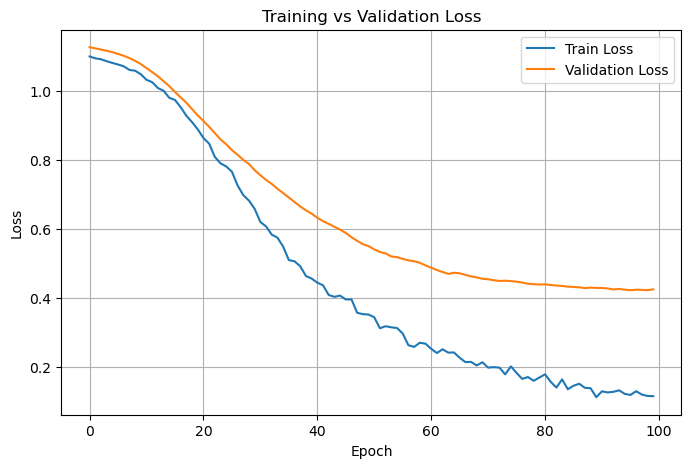

100%|████████████████████████████████████████████| 2/2 [00:00<00:00, 828.83it/s]

Test Accuracy: 0.9142857142857143
Test Precision: 0.9666666666666667
Test Recall: 0.7999999999999999
Test f1: 0.8395989974937343
Test conf_matrix:
[[27  0  0]
 [ 3  2  0]
 [ 0  0  3]]


In [25]:
class SingleLayerModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        # input layer, starting with 512 since i've not seen 1024 before, setting high dropout
        self.input_layer = nn.Sequential(nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.3))

        # hidden layer, reducing dims further
        self.hidden_layer = nn.Sequential(nn.Linear(256, 32), nn.ReLU(), nn.Dropout(0.3))

        #self.hidden_layer_2 = nn.Sequential(nn.Linear(128, 32), nn.ReLU(), nn.Dropout(0.3))

        # output layer without softmax
        self.output_layer = nn.Linear(32, 3)

        # all together now
        self.net = nn.Sequential(self.input_layer, self.hidden_layer, self.output_layer)
    
    def forward(self, x):
        return self.net(x)
    

num_epochs = 100 # idk apparently for tf-idf you need large epochs
batch_size = 32
model5 = SingleLayerModel(X_train.shape[1])
model5.to(device)
print(model5.net)

weights5 = 1.0 / np.bincount(y_train.values)
weights5 = weights5 / weights5.sum()
weights5 = torch.tensor(weights5, dtype=torch.float32).to(device)
criterion5 = nn.CrossEntropyLoss(weight=torch.tensor(weights5, device=device))

lr = 0.0001 # making this v small since we have less data
optimizer5 = torch.optim.Adam(model5.parameters(), lr=lr)

X_train_dense = torch.tensor(X_train.toarray(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
train_dataset = TensorDataset(X_train_dense, y_train_tensor)

X_val_dense = torch.tensor(X_val.toarray(), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
val_dataset = TensorDataset(X_val_dense, y_val_tensor)

# shuffling right now but I'm not sure if we should based on timestamps
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

train_loss_list5, val_loss_list5 = [], []
for epoch in range(num_epochs):
    #print(f"Epoch {epoch}")
    train_loss_list5.append(train(train_dataloader, model5, criterion5, optimizer5, device))
    val_loss_list5.append(val(val_dataloader, model5, criterion5, device))

plt.figure(figsize=(8,5))
plt.plot(train_loss_list5, label="Train Loss")
plt.plot(val_loss_list5, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# X_test_dense = torch.tensor(X_test.toarray(), dtype=torch.float32)
# y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)
# test_dataset = TensorDataset(X_test_dense, y_test_tensor)
# test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# results5 = actual_vs_pred(test_dataloader, model5, device)
results5 = testing(X_test, y_test, model5, device)

print(f"Test Accuracy: {accuracy_score(results5["actual"], results5["predicted"])}")
print(f"Test Precision: {precision_score(results5["actual"], results5["predicted"], average="macro")}")
print(f"Test Recall: {recall_score(results5["actual"], results5["predicted"], average="macro")}")
print(f"Test f1: {f1_score(results5["actual"], results5["predicted"], average="macro")}")
print(f"Test conf_matrix:\n{confusion_matrix(results5["actual"], results5["predicted"])}")

In [ ]:
class ChangedDimModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        # input layer, starting with 512 since i've not seen 1024 before, setting high dropout
        self.input_layer = nn.Sequential(nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.3))

        # hidden layer, reducing dims further
        self.hidden_layer = nn.Sequential(nn.Linear(256, 32), nn.ReLU(), nn.Dropout(0.3))

        self.hidden_layer_2 = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Dropout(0.3))

        # output layer without softmax
        self.output_layer = nn.Linear(16, 3)

        # all together now
        self.net = nn.Sequential(self.input_layer, self.hidden_layer, self.hidden_layer_2, self.output_layer)
    
    def forward(self, x):
        return self.net(x)
    

num_epochs = 100 # idk apparently for tf-idf you need large epochs
batch_size = 32
model6 = ChangedDimModel(X_train.shape[1])
model6.to(device)
print(model6.net)

weights5 = 1.0 / np.bincount(y_train.values)
weights5 = weights5 / weights5.sum()
weights5 = torch.tensor(weights5, dtype=torch.float32).to(device)
criterion5 = nn.CrossEntropyLoss(weight=torch.tensor(weights5, device=device))

lr = 0.0001 # making this v small since we have less data
optimizer5 = torch.optim.Adam(model5.parameters(), lr=lr)

X_train_dense = torch.tensor(X_train.toarray(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
train_dataset = TensorDataset(X_train_dense, y_train_tensor)

X_val_dense = torch.tensor(X_val.toarray(), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
val_dataset = TensorDataset(X_val_dense, y_val_tensor)

# shuffling right now but I'm not sure if we should based on timestamps
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

train_loss_list5, val_loss_list5 = [], []
for epoch in range(num_epochs):
    #print(f"Epoch {epoch}")
    train_loss_list5.append(train(train_dataloader, model5, criterion5, optimizer5, device))
    val_loss_list5.append(val(val_dataloader, model5, criterion5, device))

plt.figure(figsize=(8,5))
plt.plot(train_loss_list5, label="Train Loss")
plt.plot(val_loss_list5, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# X_test_dense = torch.tensor(X_test.toarray(), dtype=torch.float32)
# y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)
# test_dataset = TensorDataset(X_test_dense, y_test_tensor)
# test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# results5 = actual_vs_pred(test_dataloader, model5, device)
results5 = testing(X_test, y_test, model5, device)

print(f"Test Accuracy: {accuracy_score(results5["actual"], results5["predicted"])}")
print(f"Test Precision: {precision_score(results5["actual"], results5["predicted"], average="macro")}")
print(f"Test Recall: {recall_score(results5["actual"], results5["predicted"], average="macro")}")
print(f"Test f1: {f1_score(results5["actual"], results5["predicted"], average="macro")}")
print(f"Test conf_matrix:\n{confusion_matrix(results5["actual"], results5["predicted"])}")

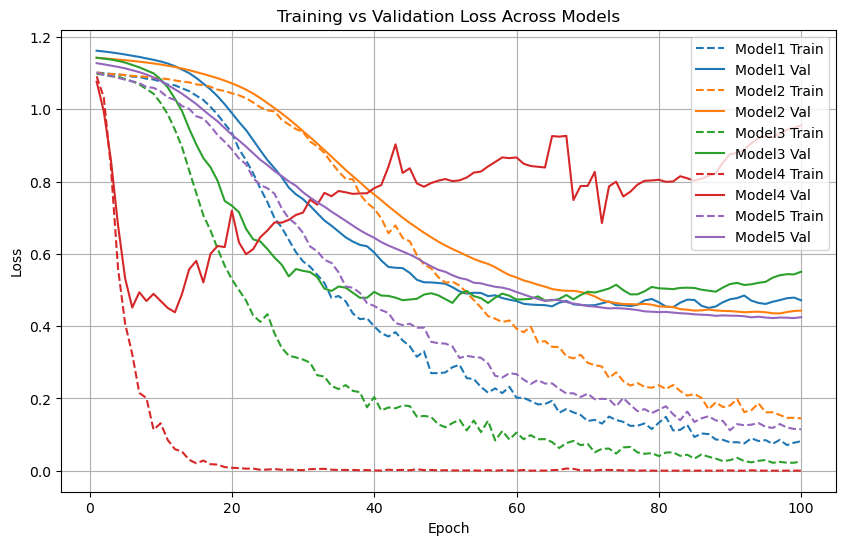

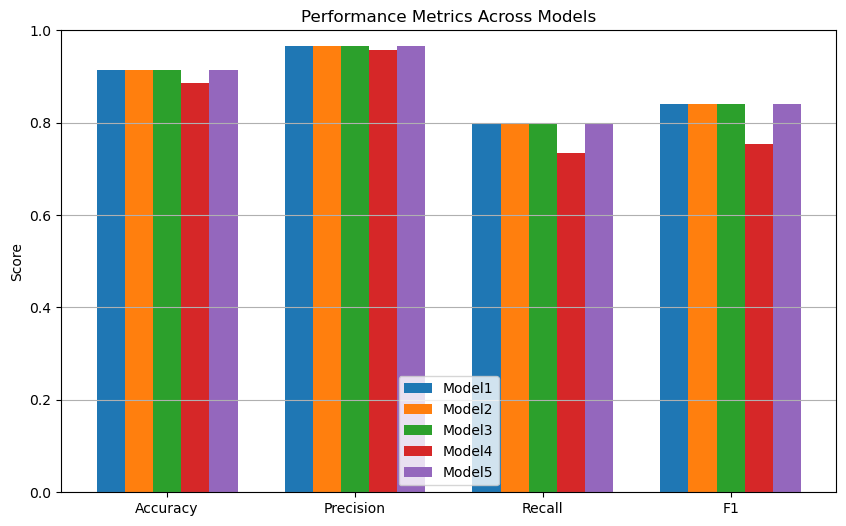

In [26]:
# runs separated by color, train is dash, val is solid
# histogram for scores

import matplotlib.pyplot as plt
import numpy as np

# Example: collected metrics from 5 models
models = ["Model1", "Model2", "Model3", "Model4", "Model5", "Model6", "Model7", "Model8", "Model9"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:", "tab:", "tab:", "tab:"]

# Model 1: Best model
# Model 2: Increase Batch Size
# Model 3: Decrease Batch Size
# Model 4: Increase Learning Rate
# Model 5: Single hidden Layer
# Model 6: Changing Hidden Dimensions
# Model 7: Dropout (increase)
# Model 8: changing rolling window size
# Model 9: SMOTE minority vs not majority

# Replace these lists with your actual stored train/val losses and results
train_losses_list = [train_loss_list1, train_loss_list2, train_loss_list3, train_loss_list4, train_loss_list5, train_loss_list6, train_loss_list7, train_loss_list8, train_loss_list9]
val_losses_list = [val_loss_list1, val_loss_list2, val_loss_list3, val_loss_list4, val_loss_list5, val_loss_list6, val_loss_list7, val_loss_list8, val_loss_list9]
results_list = [results1, results2, results3, results4, results5, results6, results7, results8, results9]

# --- Plot Loss Curves ---
plt.figure(figsize=(10,6))
for i, model_name in enumerate(models):
    epochs = range(1, len(train_losses_list[i])+1)
    plt.plot(epochs, train_losses_list[i], linestyle='--', color=colors[i], label=f"{model_name} Train")
    plt.plot(epochs, val_losses_list[i], linestyle='-', color=colors[i], label=f"{model_name} Val")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Across Models")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot Metrics Histogram ---
metrics = ["Accuracy", "Precision", "Recall", "F1"]
metric_values = []

for results in results_list:
    acc = accuracy_score(results["actual"], results["predicted"])
    prec = precision_score(results["actual"], results["predicted"], average="macro")
    rec = recall_score(results["actual"], results["predicted"], average="macro")
    f1 = f1_score(results["actual"], results["predicted"], average="macro")
    metric_values.append([acc, prec, rec, f1])

metric_values = np.array(metric_values)  # shape: (num_models, 4)

x = np.arange(len(metrics))
width = 0.15

plt.figure(figsize=(10,6))
for i in range(len(models)):
    plt.bar(x + i*width, metric_values[i], width, color=colors[i], label=models[i])

plt.xticks(x + width*2, metrics)
plt.ylabel("Score")
plt.title("Performance Metrics Across Models")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y')
plt.show()
